<a href="https://colab.research.google.com/github/loicPf/test_ia/blob/main/Demo_Biais_Donnees_Attenuations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Démo Colab — Identifier les biais courants et les atténuer
Cette démo accompagne la présentation **"Identifier les biais les plus courants et leurs atténuations"**.

**Objectifs (à la fin, vous saurez) :**
- détecter un **biais de sélection** (sous-représentation d’un groupe)  
- mesurer l’impact sur un modèle (performance globale **et** par groupe)  
- appliquer des techniques simples d’atténuation : **stratification**, **rééquilibrage**, **pondération**  
- évaluer les **risques résiduels** et documenter

> Dataset : **Adult Census Income** via `fetch_openml` (open-source, accessible directement depuis Colab).


## Plan
1. Charger + explorer le dataset (distribution des groupes)
2. Créer un dataset **biaisé** (80% d’hommes) → biais de sélection
3. Entraîner un modèle simple (Logistic Regression) + métriques par groupe
4. Atténuer : **échantillonnage stratifié** + **pondération** + (option) **SMOTE**
5. Simuler un **biais de mesure** (labels bruités) et observer l’impact
6. Mettre en place une mini **surveillance** (tableau de métriques + plots)


In [ ]:
# Cellule 1 — Installation (Colab)
# (si vous êtes sur Colab, cette cellule suffit)
!pip -q install -U scikit-learn imbalanced-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 91.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.0 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.0 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.0 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.0 which is incompatible.


In [ ]:
#Imports + config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score

# Optionnel (si vous voulez SMOTE)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option("display.max_columns", 200)
np.random.seed(42)

In [ ]:
#Charger un dataset open-source (Adult Census Income)
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy()

print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.isna().mean()

age               0.000000
workclass         0.057307
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        0.057512
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.017546
class             0.000000
dtype: float64

In [ ]:
# Nettoyage minimal + renommage de la cible
# La cible est 'class' : <=50K ou >50K
df = df.dropna().copy()

df["income_high"] = (df["class"] == ">50K").astype(int)
df = df.drop(columns=["class"])

# # Choix d’un attribut "sensible" : sex (Male/Female)
# df["sex"].value_counts(dropna=False)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income_high
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


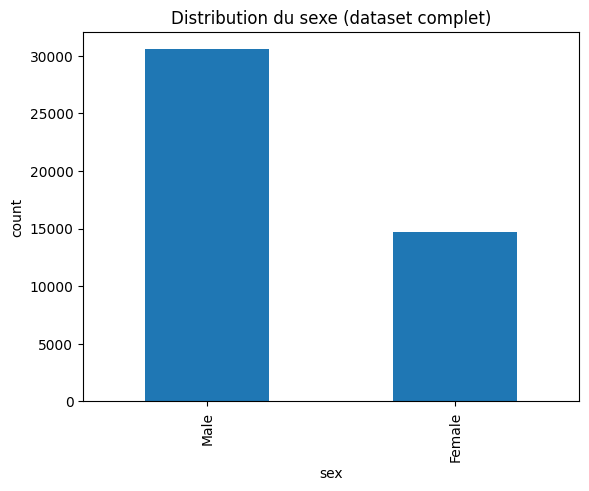

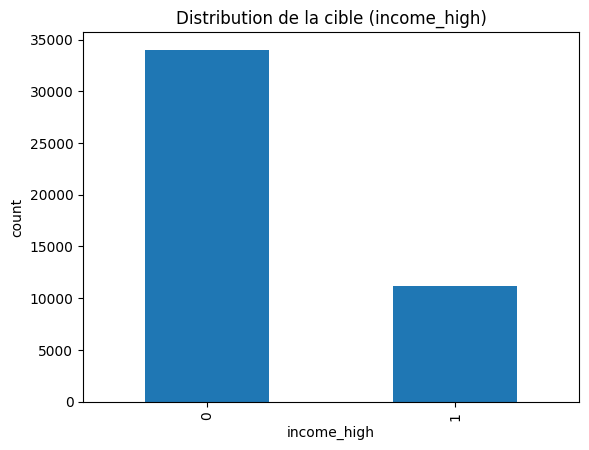

In [ ]:
# Explorer la distribution (repérage d’un biais potentiel)
def plot_bar(series, title):
    counts = series.value_counts()
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel(series.name)
    ax.set_ylabel("count")
    plt.show()

plot_bar(df["sex"], "Distribution du sexe (dataset complet)")
plot_bar(df["income_high"], "Distribution de la cible (income_high)")
# plot_bar(df["race"], "race")

### Mini-problème 1 (2 min)
**Question :** si un groupe est sous-représenté dans les données d’entraînement, qu’est-ce que ça peut provoquer sur le modèle ?

> On va le simuler en créant un dataset artificiellement biaisé : **90% d’hommes** (biais de sélection).

In [ ]:
# Créer un dataset biaisé (biais de sélection)
# Objectif : ~80% Male
df_m_80 = df[df["sex"] == "Male"]
df_f_80 = df[df["sex"] == "Female"]

target_male_ratio_80 = 0.90
n_total = 6000  # on prend un sous-échantillon pour aller vite
n_m_80 = int(n_total * target_male_ratio_80)
n_f_80 = n_total - n_m_80

df_biased_80 = pd.concat([
    df_m_80.sample(n=min(n_m_80, len(df_m_80)), random_state=42),
    df_f_80.sample(n=min(n_f_80, len(df_f_80)), random_state=42),
], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset biaisé:", df_biased_80.shape)
df_biased_80["sex"].value_counts(normalize=True)

Dataset biaisé: (6000, 15)


sex
Male      0.9
Female    0.1
Name: proportion, dtype: float64

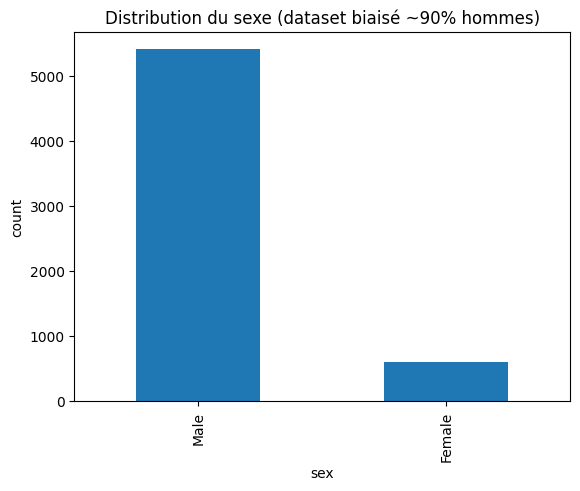

In [ ]:
# Visualiser la nouvelle distribution
plot_bar(df_biased_80["sex"], "Distribution du sexe (dataset biaisé ~90% hommes)")

In [ ]:
# Créer un dataset biaisé (biais de sélection)
# Objectif : 50% Male / 50% Female
# ET dans chaque sexe : 50% income_high=1 ( >50K ) et 50% income_high=0 ( <=50K )


# 1) Séparer par sexe
df_m_50 = df[df["sex"] == "Male"]
df_f_50 = df[df["sex"] == "Female"]

# 2) Paramètres
target_male_ratio_50 = 0.50
n_total = 6000  # sous-échantillon
n_m_50 = int(n_total * target_male_ratio_50)
n_f_50 = n_total - n_m_50

# 3) Dans chaque sexe : 50% income_high=1 et 50% income_high=0
# => nombre voulu par sous-groupe
n_m_pos = n_m_50 // 2
n_m_neg = n_m_50 - n_m_pos

n_f_pos = n_f_50 // 2
n_f_neg = n_f_50 - n_f_pos

# 4) Construire les sous-groupes
# Male
df_m_pos = df_m_50[df_m_50["income_high"] == 1]
df_m_neg = df_m_50[df_m_50["income_high"] == 0]

# Female
df_f_pos = df_f_50[df_f_50["income_high"] == 1]
df_f_neg = df_f_50[df_f_50["income_high"] == 0]

# 5) Échantillonnage (avec sécurité min(...) si manque d'exemples)
m_pos_n = min(n_m_pos, len(df_m_pos))
m_neg_n = min(n_m_neg, len(df_m_neg))
f_pos_n = min(n_f_pos, len(df_f_pos))
f_neg_n = min(n_f_neg, len(df_f_neg))

# (Optionnel) Alerte si on n'arrive pas à atteindre les quotas
if m_pos_n < n_m_pos or m_neg_n < n_m_neg or f_pos_n < n_f_pos or f_neg_n < n_f_neg:
    print("Attention : pas assez d'exemples dans au moins un sous-groupe pour respecter exactement les quotas.")
    print(f"Male >50K  : demandé {n_m_pos}, dispo {len(df_m_pos)}, pris {m_pos_n}")
    print(f"Male <=50K : demandé {n_m_neg}, dispo {len(df_m_neg)}, pris {m_neg_n}")
    print(f"Female >50K: demandé {n_f_pos}, dispo {len(df_f_pos)}, pris {f_pos_n}")
    print(f"Female <=50K: demandé {n_f_neg}, dispo {len(df_f_neg)}, pris {f_neg_n}")

# 6) Concaténer les 4 sous-échantillons + mélanger + reset index
df_biased_50 = pd.concat([
    df_m_pos.sample(n=m_pos_n, random_state=42),
    df_m_neg.sample(n=m_neg_n, random_state=42),
    df_f_pos.sample(n=f_pos_n, random_state=42),
    df_f_neg.sample(n=f_neg_n, random_state=42),
], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# 7) Vérification rapide
print("Dataset biaisé:", df_biased_50.shape)
print("\nRépartition sexe (ratio) :")
display(df_biased_50["sex"].value_counts(normalize=True))

print("\nRépartition income_high (ratio) :")
display(df_biased_50["income_high"].value_counts(normalize=True))

print("\nRépartition croisée sexe x income_high (ratio par sexe) :")
check = pd.crosstab(df_biased_50["sex"], df_biased_50["income_high"], normalize="index")
display(check)


Dataset biaisé: (6000, 15)

Répartition sexe (ratio) :


sex
Female    0.5
Male      0.5
Name: proportion, dtype: float64


Répartition income_high (ratio) :


income_high
0    0.5
1    0.5
Name: proportion, dtype: float64


Répartition croisée sexe x income_high (ratio par sexe) :


income_high,0,1
sex,,
Female,0.5,0.5
Male,0.5,0.5


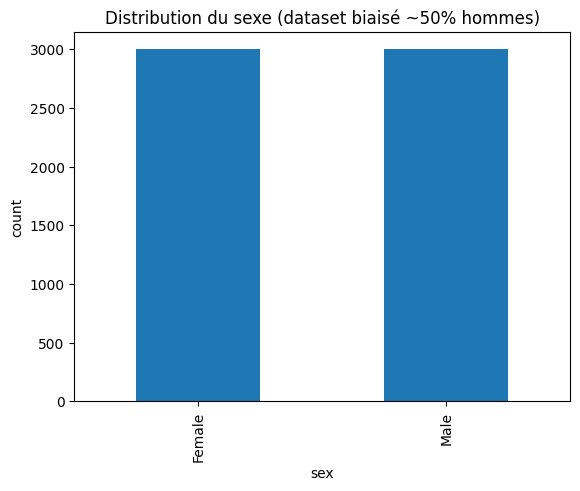

In [ ]:
# Visualiser la nouvelle distribution
plot_bar(df_biased_50["sex"], "Distribution du sexe (dataset biaisé ~50% hommes)")


Comptages (income_high x sex) :
Pourcentages (normalisés par income_high) :


sex,Female,Male
income_high,,
0,50.0,50.0
1,50.0,50.0


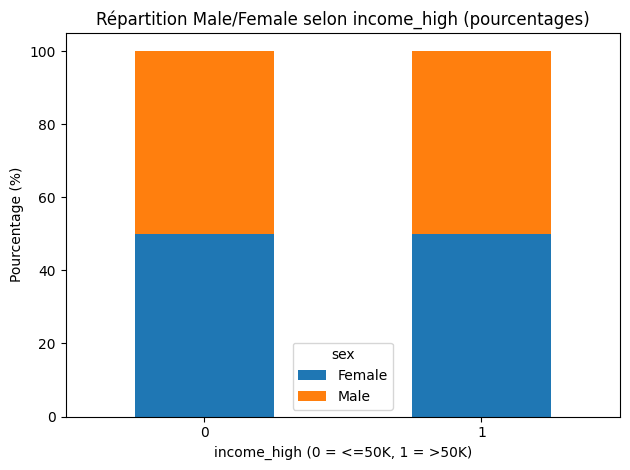

In [ ]:


# --- 1) Tableau de comptage : Sex x Income_high ---
ct = pd.crosstab(df_biased_50["income_high"], df_biased_50["sex"])  # lignes=income_high, colonnes=sex
print("Comptages (income_high x sex) :")
# display(ct)

# # --- 2) Graphe en effectifs (barres empilées) ---
# ax = ct.plot(kind="bar", stacked=True)
# ax.set_title("Répartition Male/Female selon income_high (effectifs)")
# ax.set_xlabel("income_high (0 = <=50K, 1 = >50K)")
# ax.set_ylabel("Nombre d'individus")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

# --- 3) Graphe en pourcentages (normalisé par income_high) ---
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100  # % par ligne (par income_high)
print("Pourcentages (normalisés par income_high) :")
display(ct_pct.round(2))

ax = ct_pct.plot(kind="bar", stacked=True)
ax.set_title("Répartition Male/Female selon income_high (pourcentages)")
ax.set_xlabel("income_high (0 = <=50K, 1 = >50K)")
ax.set_ylabel("Pourcentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Mesurer l’impact sur un modèle
On va entraîner **le même pipeline** sur :
- dataset **complet** (référence)
- dataset **biaisé** (sélection)

Ensuite : métriques globales **et** métriques **par groupe** (Male/Female).

In [ ]:
#Fonction utilitaire : métriques par groupe (fairness quick-check)
def group_report(y_true, y_pred, group, positive_label=1):
    dfm = pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "group": group})
    rows = []
    for g, sub in dfm.groupby("group"):
        yt = sub["y_true"].values
        yp = sub["y_pred"].values

        acc = accuracy_score(yt, yp)
        prec = precision_score(yt, yp, zero_division=0)
        rec = recall_score(yt, yp, zero_division=0)  # TPR
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        pred_pos_rate = (yp == positive_label).mean()  # demographic parity proxy
        rows.append({
            "group": g,
            "n": len(sub),
            "accuracy": acc,
            "precision": prec,
            "recall_tpr": rec,
            "fpr": fpr,
            "pred_positive_rate": pred_pos_rate
        })
    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    # écarts entre groupes (simple)
    if len(out) == 2:
        out["gap_vs_first"] = out.iloc[:, :].apply(lambda _: np.nan)
    return out

def fairness_gaps(report_df):
    # suppose 2 groupes
    if report_df.shape[0] != 2:
        return {}
    a = report_df.iloc[0]
    b = report_df.iloc[1]
    return {
        "demographic_parity_diff": float(b["pred_positive_rate"] - a["pred_positive_rate"]),
        "equal_opportunity_diff_tpr": float(b["recall_tpr"] - a["recall_tpr"]),
        "fpr_diff": float(b["fpr"] - a["fpr"]),
        "accuracy_diff": float(b["accuracy"] - a["accuracy"])
    }

In [ ]:
# Préparer features/target + pipeline ML simple
TARGET = "income_high"
SENSITIVE = "sex"

def make_pipeline(X: pd.DataFrame):
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    preproc = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ],
        remainder="drop"
    )

    clf = LogisticRegression(max_iter=500, n_jobs=None)
    pipe = Pipeline([("preprocess", preproc), ("clf", clf)])
    return pipe

FEATURES = [c for c in df.columns if c != TARGET]  # on garde 'sex' car on veut analyser l'effet
# (option pédagogique) : on peut aussi tester 'sex' exclu des features plus tard

def train_eval(data: pd.DataFrame, title: str):
    X = data[FEATURES]
    y = data[TARGET].astype(int)
    g = data[SENSITIVE].astype(str)

    X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
        X, y, g, test_size=0.25, random_state=42, stratify=y
    )
    pipe = make_pipeline(X_train)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    overall = {
        "title": title,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
    }
    rep = group_report(y_test, y_pred, g_test)
    gaps = fairness_gaps(rep) if rep.shape[0] == 2 else {}
    return overall, rep, gaps

# overall_full, rep_full, gaps_full = train_eval(df.sample(n=20000, random_state=42), "Référence (dataset complet)")
overall_a, rep_a, gaps_a = train_eval(df_biased_50, "Dataset 50")
overall_b, rep_b, gaps_b = train_eval(df_biased_80, "Dataset biaisé 90")

overall_a, overall_b

({'title': 'Dataset 50',
  'n_train': 4500,
  'n_test': 1500,
  'accuracy': 0.8286666666666667,
  'precision': 0.8222222222222222,
  'recall': 0.8386666666666667},
 {'title': 'Dataset biaisé 90',
  'n_train': 4500,
  'n_test': 1500,
  'accuracy': 0.8186666666666667,
  'precision': 0.7058823529411765,
  'recall': 0.6374133949191686})

In [ ]:
# Résultats : métriques par groupe
print("=== dataset (50%) ===")
display(rep_a)
print("Gaps:", gaps_a)

print("\n=== Dataset biaisé (90%) ===")
display(rep_b)
print("Gaps:", gaps_b)

=== dataset (50%) ===


,group,n,accuracy,precision,recall_tpr,fpr,pred_positive_rate,gap_vs_first
0,Female,756,0.850529,0.854545,0.852332,0.151351,0.509259,NaN
1,Male,744,0.806452,0.789474,0.824176,0.210526,0.510753,NaN


Gaps: {'demographic_parity_diff': 0.0014934289127837008, 'equal_opportunity_diff_tpr': -0.028155782041792476, 'fpr_diff': 0.05917496443812231, 'accuracy_diff': -0.04407748762587482}

=== Dataset biaisé (90%) ===


,group,n,accuracy,precision,recall_tpr,fpr,pred_positive_rate,gap_vs_first
0,Female,143,0.895105,0.588235,0.555556,0.05600,0.118881,NaN
1,Male,1357,0.810612,0.711230,0.640964,0.11465,0.275608,NaN


Gaps: {'demographic_parity_diff': 0.15672683985137928, 'equal_opportunity_diff_tpr': 0.08540829986613119, 'fpr_diff': 0.05864968152866242, 'accuracy_diff': -0.08449325177401812}


## Interprétation des résultats (métriques par groupe)

Nous comparons deux cas :

1) **Dataset équilibré (50% hommes / 50% femmes + 50/50 income_high dans chaque sexe)**  
2) **Dataset déséquilibré (≈90% hommes, distribution income_high non équilibrée)**

### 1) Dataset équilibré (50%)
- Le **taux de prédiction “>50K”** (`pred_positive_rate`) est quasi identique entre femmes et hommes (~0.51).  
  ➜ Le **gap de parité démographique** est donc **presque nul**, ce qui indique des sorties très proches entre groupes.
- Le **recall/TPR** est proche entre groupes : le modèle détecte les vrais “>50K” de manière relativement comparable.  
  ➜ L’écart d’**equal opportunity** est faible.
- Point de vigilance : le **FPR** est plus élevé chez les hommes.  
  ➜ Le modèle génère plus de faux positifs “>50K” chez les hommes, ce qui peut réduire leur accuracy.

### 2) Dataset déséquilibré (≈90% hommes)
- Le modèle prédit “>50K” beaucoup plus souvent pour les hommes que pour les femmes.  
  ➜ Le **gap de parité démographique** devient important.
- Le **TPR des femmes** baisse : le modèle rate davantage de femmes qui sont réellement “>50K”.  
  ➜ Cela signifie plus de **faux négatifs** chez les femmes (problème d’equal opportunity).
- Attention : l’échantillon femmes est petit dans ce cas, donc les métriques côté femmes sont plus variables.  
  Néanmoins, les écarts observés sont suffisamment grands pour indiquer un effet réel du biais de sélection.

## Conclusion
Le **dataset équilibré** produit un modèle plus “fair” : il réduit fortement les écarts de prédiction entre groupes.  
Le **dataset déséquilibré** amplifie les disparités : le modèle favorise le groupe majoritaire et généralise moins bien sur le groupe minoritaire.  
>> D’où l’importance de **vérifier la représentativité des données** et de **suivre des métriques par groupe**, pas seulement la performance globale.
